Comparing Apple Watch Series 10 with a rival product of Sumsung Galaxy Watch Ultra

# Getting Data for Apple Watch Series 10

Preparing Youtube API & Collecting Information

In [3]:
import pandas as pd
from googleapiclient.discovery import build
from googleapiclient.errors import HttpError
import dateutil.parser  # From processing date/time values.

from google.colab import userdata

youtube_api_key = userdata.get('YOUTUBE_API')
youtube = build("youtube", "v3", developerKey=youtube_api_key)

request = youtube.search().list(part="snippet",
                                q="Apple Watch Series 10 Reviews", # write key word
                                maxResults=20, # how many results to consider
                                relevanceLanguage="en")
result = request.execute()

Examining, Extracting Relevant Features & Saving them

In [ ]:
video_ids = []
for item in result["items"]:
    if "videoId" in item["id"]:
        video_ids.append(item["id"]["videoId"])
video_ids = ",".join(video_ids)
print(video_ids)

request = youtube.videos().list(id=video_ids, part="snippet,statistics")
result = request.execute()

result["items"][0]

Ir1xi2zeuug,68eAMjWqOUQ,lcCHccKnd20,C2Iu2xY0hHo,hpNuLka-tH4,8AuAv0eQlBI,Dkkzdp6tnkk,De-EpOh3tbo,Gq-7oRka_Jk,sAE9cmHHOwc,0BP5c04X2Qs,jw69yhWkjgA,9-0scuBkfEw,0F9e1TzJctg,O3KLAyQWktI,riw9Vh8ja-I,8eWLi8Sm0H4,CHSRzPbnfMw,bh6LdziZpYo,h3-7OZ2Yt0s


{'kind': 'youtube#video',
 'etag': 'j2ba_LKXrUk6FZdAhtHQaWhCyuw',
 'id': 'Ir1xi2zeuug',
 'snippet': {'publishedAt': '2024-09-17T12:03:18Z',
  'channelId': 'UCBJycsmduvYEL83R_U4JriQ',
  'title': 'Apple Watch Series 10 Review: This is It?',
  'description': 'So... this is the big "redesign," eh?\n\nGet $350 off the EightSleep Pod 4 Ultra or $200 off the Pod 4 at https://eightsleep.com/MKBHD\n\nApple Watch Series 10: https://geni.us/LBuel0\nApple Watch Ultra 2: https://geni.us/yoji7\n\nMKBHD Merch: http://shop.MKBHD.com\n\nTech I\'m using right now: https://www.amazon.com/shop/MKBHD\n\nIntro Track: Jordyn Edmonds https://lnk.to/jordynedmonds\nPlaylist of MKBHD Intro music: https://goo.gl/B3AWV5\n\nWatch provided by Apple for review.\n\n~\nhttp://twitter.com/MKBHD\nhttp://instagram.com/MKBHD\nhttp://facebook.com/MKBHD',
  'thumbnails': {'default': {'url': 'https://i.ytimg.com/vi/Ir1xi2zeuug/default.jpg',
    'width': 120,
    'height': 90},
   'medium': {'url': 'https://i.ytimg.com/vi/Ir1x

In [ ]:
videos = []  # shows information for all 20 vds, with features/dicrionaries we want to see
for item in result["items"]:
    videos.append({
        "id": item["id"],
        "channel": item["snippet"]["channelTitle"],
        "publishedAt": dateutil.parser.parse(item["snippet"]["publishedAt"]),
        "title": item["snippet"]["title"],
        "description": item["snippet"]["description"].replace("\n", " "),
        "views": item["statistics"].get("viewCount", 0),  # .get(X, 0) means to use 0 when X does not exist
        "likes": item["statistics"].get("likeCount", 0),
        "commentCount": item["statistics"].get("commentCount", 0)
    })

Saving file as .csv

In [ ]:
df_videos = pd.DataFrame(videos)
df_videos.to_csv("Apple_Watch_videos.csv", index=False)

# Getting Data for Samsung Galaxy Watch Ultra

Repeating the same steps for Samsung Galaxy Watch Ultra

In [ ]:
request = youtube.search().list(part="snippet",
                                q="Samsung Galaxy Watch Ultra Reviews",
                                maxResults=20,
                                relevanceLanguage="en")
result = request.execute()

video_ids = []
for item in result["items"]:
    if "videoId" in item["id"]:
        video_ids.append(item["id"]["videoId"])
video_ids = ",".join(video_ids)

request = youtube.videos().list(id=video_ids, part="snippet,statistics")
result = request.execute()

videos = []
for item in result["items"]:
    videos.append({
        "id": item["id"],
        "channel": item["snippet"]["channelTitle"],
        "publishedAt": dateutil.parser.parse(item["snippet"]["publishedAt"]),
        "title": item["snippet"]["title"],
        "description": item["snippet"]["description"].replace("\n", " "),
        "views": item["statistics"].get("viewCount", 0),
        "likes": item["statistics"].get("likeCount", 0),
        "commentCount": item["statistics"].get("commentCount", 0)
    })

In [ ]:
df_videos = pd.DataFrame(videos)
df_videos.to_csv("Samsung_Watch_videos.csv", index=False)

# Loading & inspecting both files

In [ ]:
# loading files

apple_df = pd.read_csv("/content/Apple_Watch_videos.csv")
samsung_df = pd.read_csv("/content/Samsung_Watch_videos.csv")


In [ ]:
samsung_df.head()

,id,channel,publishedAt,title,description,views,likes,commentCount
0,nIEnB90vzyw,Chase the Summit,2026-08-01 19:31:06+00:00,Samsung Galaxy Watch Ultra 2 In-Depth Review (...,Samsung Galaxy Watch Ultra 2 Amazon: https://g...,50040,1365,231
1,YHNd6_cptPA,Patrick Rambles,2026-08-03 13:00:05+00:00,Samsung Galaxy Watch Ultra 2 (Two Weeks Later)...,This is my two weeks later later review of the...,27573,859,161
2,mlh1js3QP_0,Everyday Legends,2024-12-27 21:00:35+00:00,Samsung Galaxy Watch Ultra Review: Is it Worth...,The Samsung Galaxy Watch Ultra is a fantastic ...,163380,1144,145
3,f1FhBqrVp_k,ben's gadget reviews,2026-08-02 05:46:56+00:00,Samsung Galaxy Watch Ultra 2 Review: The Do-It...,The Samsung Galaxy Watch Ultra 2 is a bit thin...,17166,462,83
4,pwHPUaxBVbQ,DKHD,2026-08-02 17:04:21+00:00,Samsung Galaxy Watch Ultra 2 - 1 WEEK LATER (B...,Samsung Galaxy Watch Ultra 2 1 week later is h...,5737,96,22


In [ ]:
# inspecting files
samsung_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            20 non-null     object
 1   channel       20 non-null     object
 2   publishedAt   20 non-null     object
 3   title         20 non-null     object
 4   description   19 non-null     object
 5   views         20 non-null     int64 
 6   likes         20 non-null     int64 
 7   commentCount  20 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 1.4+ KB


No missing values except one missing value for description for Samsung Galaxy's Watch Ultra. It is irrelevant so does not require to be cleaned.

In [ ]:
total_apple_comments = apple_df['commentCount'].sum()
total_samsung_comments = samsung_df['commentCount'].sum()

print(f"Total comments for Apple Watch Series 10: {total_apple_comments}")
print(f"Total comments for Samsung Galaxy Watch Ultra: {total_samsung_comments}")

Total comments for Apple Watch Series 10: 9585
Total comments for Samsung Galaxy Watch Ultra: 6009


# Visualisations for Apple Watch Series 10

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Likes to Views Ratio Analysis

In [ ]:
apple_df_views = apple_df.groupby("channel").sum().sort_values("views", ascending=False)
apple_df_views["like_view_ratio"] = apple_df_views["likes"] / apple_df_views["views"]

apple_df_views.head(10)

,id,publishedAt,title,description,views,likes,commentCount,like_view_ratio
channel,,,,,,,,
Marques Brownlee,Ir1xi2zeuug,2024-09-17 12:03:18+00:00,Apple Watch Series 10 Review: This is It?,"So... this is the big ""redesign,"" eh? Get $35...",4752589,107543,5261,0.022628
GregsGadgets,CHSRzPbnfMw,2024-09-11 16:46:57+00:00,Apple Watch Series 10 VS SE! - DON'T BE FOOLED!,Apple just released a redesigned Apple Watch s...,927212,7138,372,0.007698
Hayls World,jw69yhWkjgA,2024-11-09 16:00:41+00:00,"Apple Watch Series 10 Tips, Tricks & Hidden Fe...",I'll show you how to make the Apple Watch Seri...,921950,18712,507,0.020296
Shervin Shares,lcCHccKnd20,2024-09-17 12:01:01+00:00,Apple Watch Series 10 Review (why it's finally...,Apple Watch Series 10 review. ** Watch More Vi...,521532,4754,405,0.009115
Nikias Molina,O3KLAyQWktI,2024-09-17 18:53:29+00:00,Apple Watch Series 10 Review: Why It's (Really...,"The Apple Watch Series 10 is here, and it's pa...",321608,4907,407,0.015258
DC Rainmaker,C2Iu2xY0hHo,2024-09-17 14:59:01+00:00,Apple Watch Series 10 In-Depth Review: Worth t...,Here's your complete in-depth review of the Ap...,312303,3859,315,0.012357
Nabeel Nawab,0F9e1TzJctg,2024-10-18 18:13:28+00:00,Apple Watch Series 10 Jet Black Cellular Review,Apple Watch Series 10 GPS 46mm Jet Black: http...,269809,3470,234,0.012861
Mac Address,8eWLi8Sm0H4,2024-11-30 01:14:52+00:00,Why I don’t love the Apple Watch - Series 10 R...,Visit https://www.squarespace.com/macaddress a...,258191,9283,790,0.035954
6 Months Later,68eAMjWqOUQ,2025-07-06 14:29:14+00:00,Apple Watch Series 10 Review - 6 Months Later,How has the Apple Watch Series 10 held up over...,234025,2078,168,0.008879


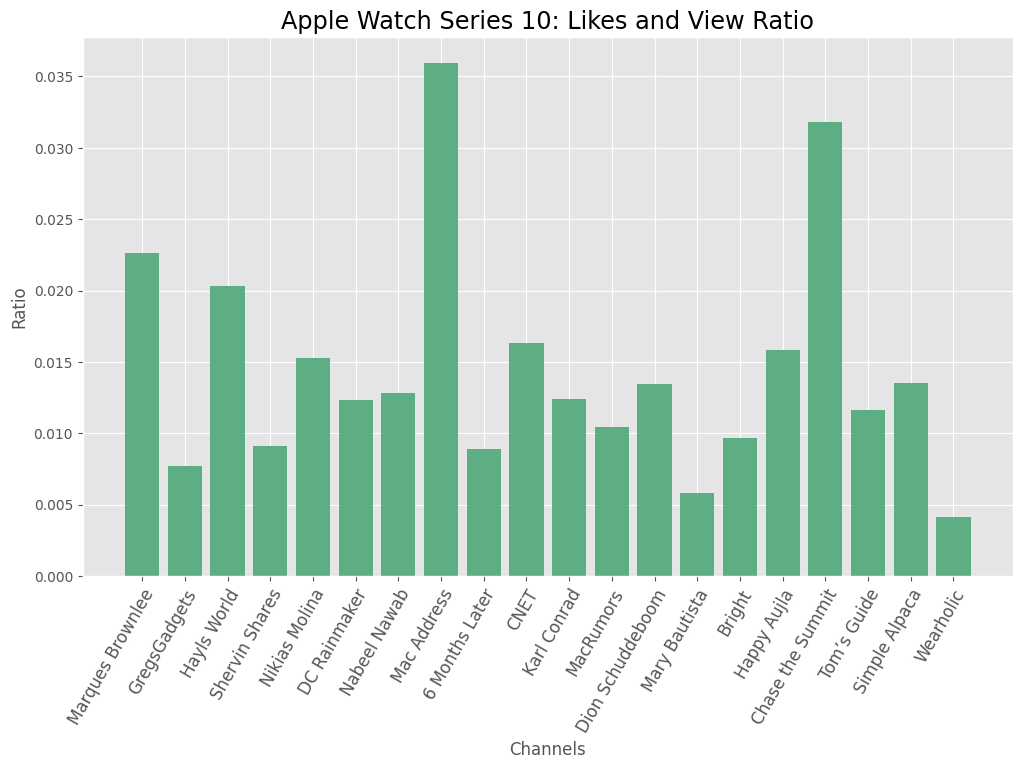

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(apple_df_views.index, apple_df_views["like_view_ratio"], color="#5DAF83")
ax.set_ylabel("Ratio")
ax.set_xlabel("Channels")

plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")
plt.title("Apple Watch Series 10: Likes and View Ratio", fontsize="xx-large")

plt.show()

### Views Analysis

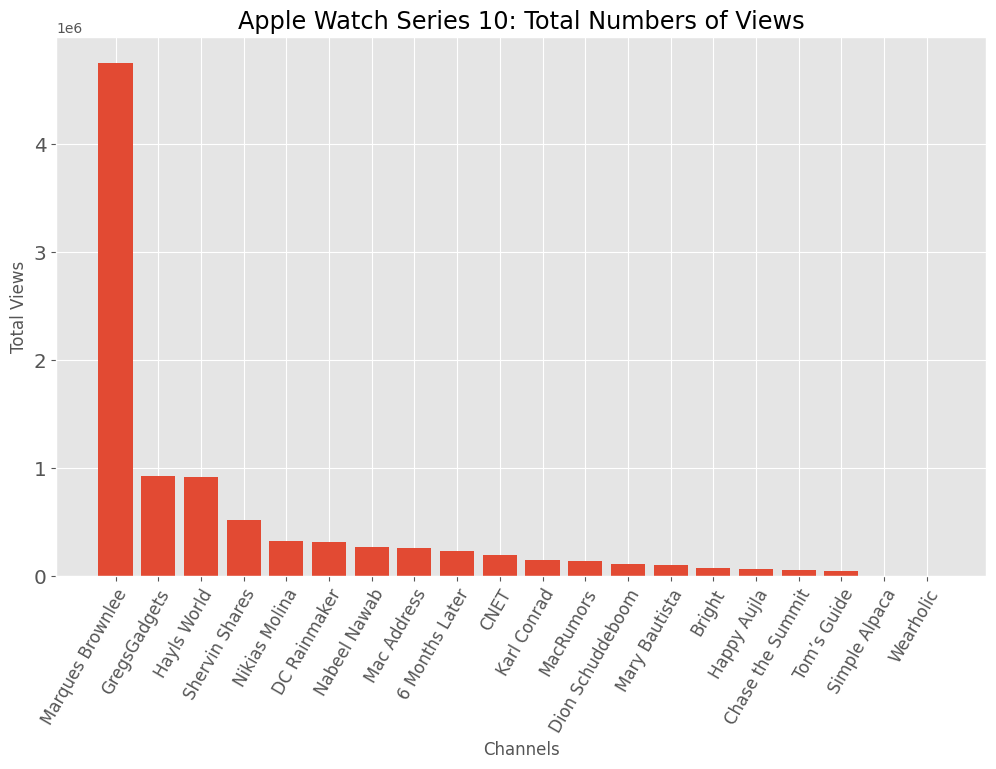

In [ ]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(apple_df_views.index, apple_df_views["views"])

ax.set_ylabel("Total Views")  # Set the label for the Y-axis.
plt.yticks(fontsize="x-large")  # Set a larger font size for the item labels on the Y-axis.
ax.set_xlabel("Channels")

# Set the labels of items on the X-axis.
# We rotate 60 degrees here so that the text won't overlap.
# Also set "ha" (horizontal alignment) to "right" and a large font size.
plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Apple Watch Series 10: Total Numbers of Views", fontsize="xx-large")  # Set the title for the whole chart.
plt.show()

The x axis, views count is decieving and not correct. The following code aims to fix this issue

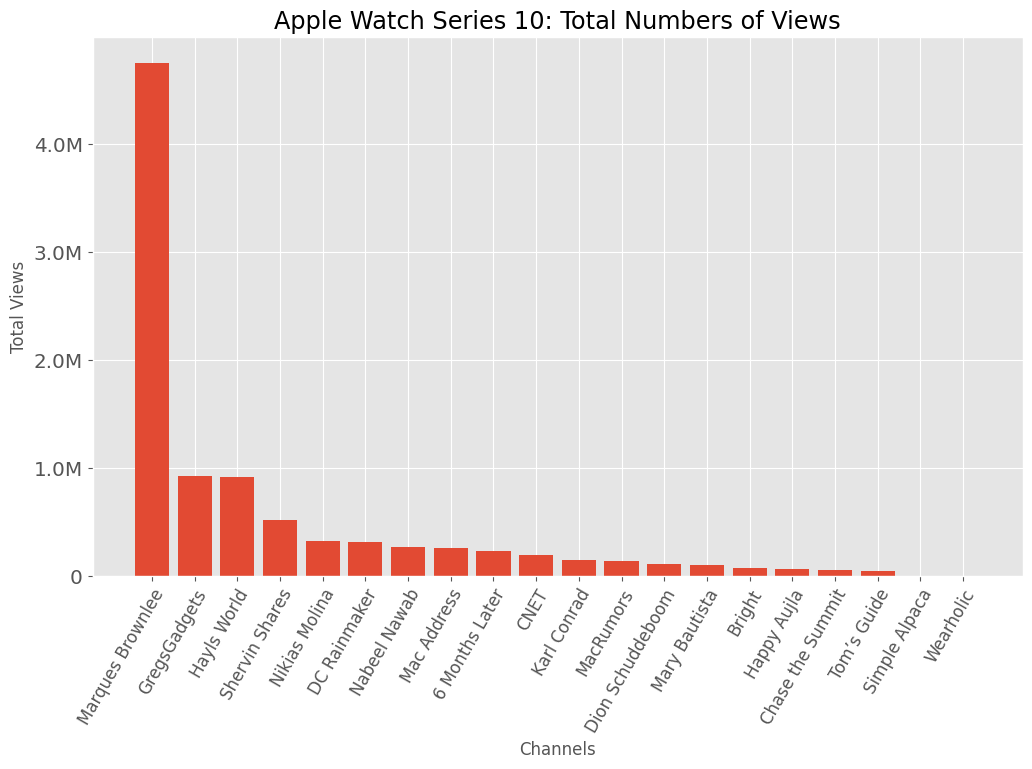

In [ ]:
plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(apple_df_views.index, apple_df_views["views"])

ax.set_ylabel("Total Views")  # Set the label for the Y-axis.
plt.yticks(fontsize="x-large")  # Set a larger font size for the item labels on the Y-axis.

ax.set_xlabel("Channels")

# Define a formatter function to display values in millions or thousands
import matplotlib.ticker as ticker
def millions_formatter(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    return f'{x:.0f}'

# Apply the formatter to the y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

# Set the labels of items on the X-axis.
# We rotate 60 degrees here so that the text won't overlap.
# Also set "ha" (horizontal alignment) to "right" and a large font size.
plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Apple Watch Series 10: Total Numbers of Views", fontsize="xx-large")  # Set the title for the whole chart.
plt.show()

### Comment Volume Analysis & Likes

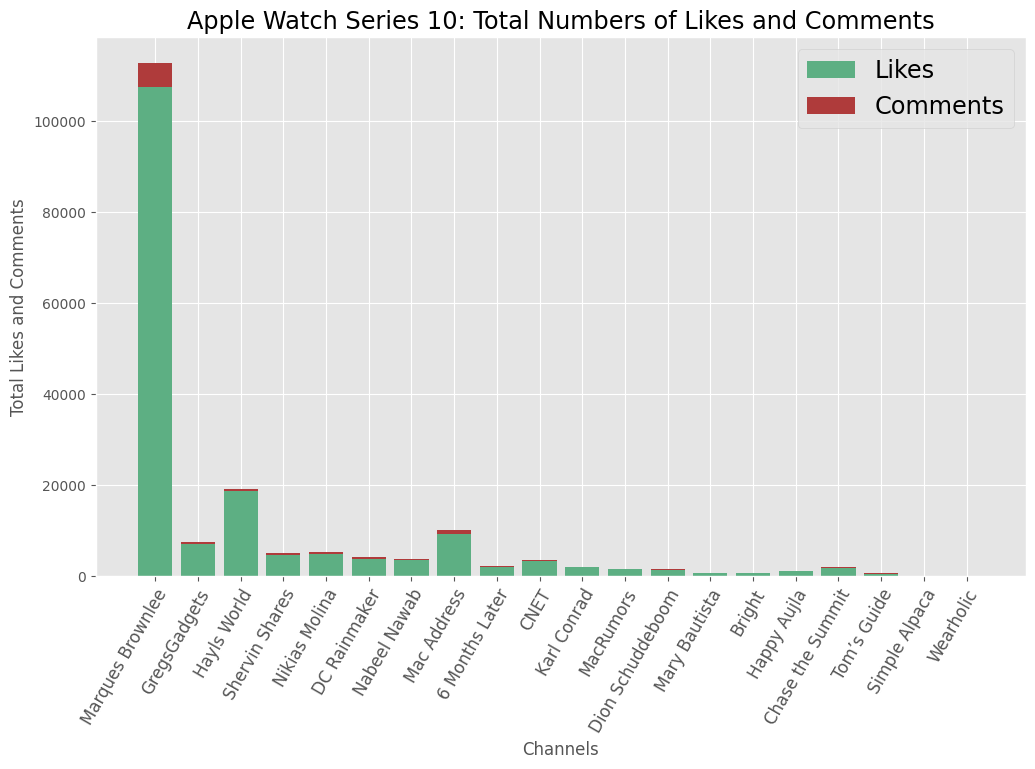

In [ ]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(apple_df_views.index, apple_df_views["likes"], color="#5DAF83")
ax.bar(apple_df_views.index, apple_df_views["commentCount"], bottom=apple_df_views["likes"], color="#AF3B3B")

ax.set_ylabel("Total Likes and Comments")
ax.set_xlabel("Channels")
plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Apple Watch Series 10: Total Numbers of Likes and Comments", fontsize="xx-large")

plt.legend(["Likes", "Comments"], fontsize="xx-large")  # Show the legend.
plt.show()

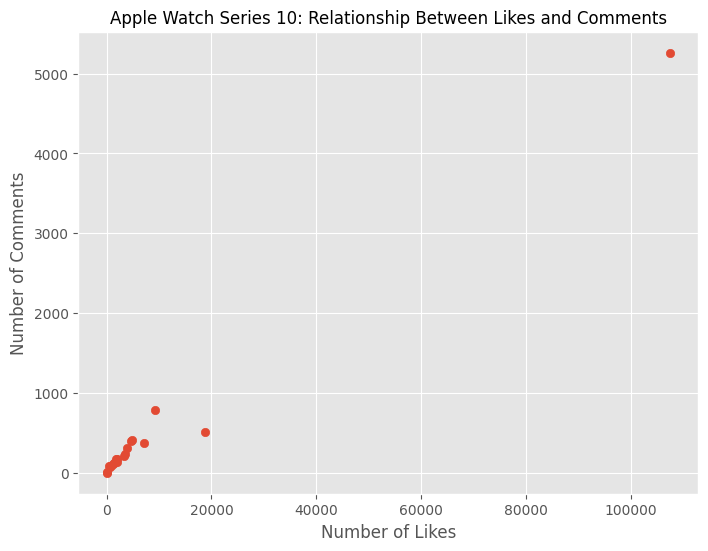

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(apple_df_views["likes"], apple_df_views["commentCount"])
plt.xlabel("Number of Likes")
plt.ylabel("Number of Comments")
plt.title("Apple Watch Series 10: Relationship Between Likes and Comments", fontsize="large")

plt.show()

### Time Series Analysis of engagement trends

In [ ]:
apple_df_months = apple_df.copy()
apple_df_months["month"] = pd.to_datetime(apple_df["publishedAt"]).apply(lambda d: d.strftime("%Y-%m"))

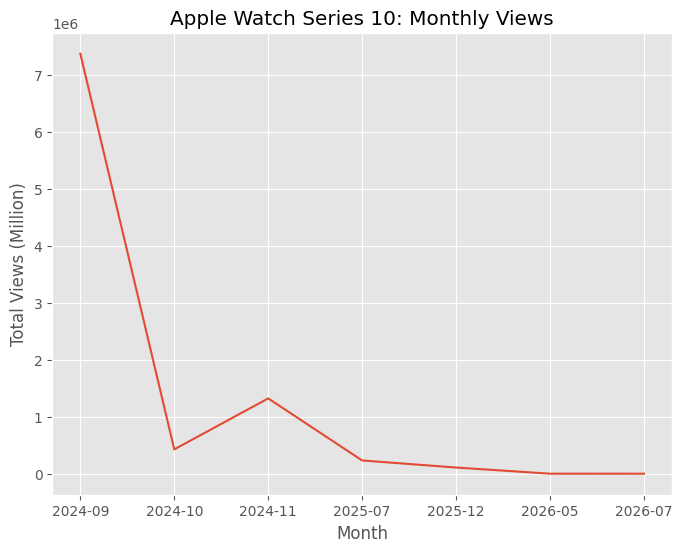

In [ ]:
apple_df_monthly_views = apple_df_months.groupby("month").sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlabel("Month")
ax.set_ylabel("Total Views (Million)")

ax.plot(apple_df_monthly_views.index, apple_df_monthly_views["views"])
plt.title("Apple Watch Series 10: Monthly Views")

plt.show()

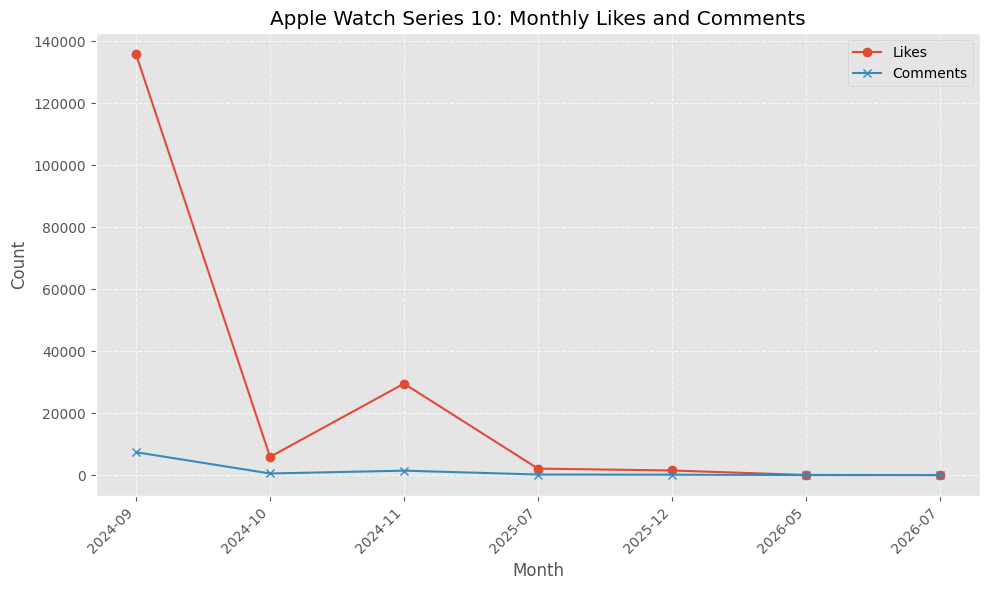

In [ ]:
apple_df_monthly_engagement = apple_df_months.groupby("month")[["likes", "commentCount"]].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(apple_df_monthly_engagement.index, apple_df_monthly_engagement["likes"], label="Likes", marker='o')
ax.plot(apple_df_monthly_engagement.index, apple_df_monthly_engagement["commentCount"], label="Comments", marker='x')

ax.set_xlabel("Month")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.title("Apple Watch Series 10: Monthly Likes and Comments")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualisations for Samsung Galaxy Watch Ultra

### Likes to Views Ratio Analysis

In [ ]:
samsung_df_views = samsung_df.groupby("channel").sum().sort_values("views", ascending=False)
samsung_df_views["like_view_ratio"] = samsung_df_views["likes"] / samsung_df_views["views"]



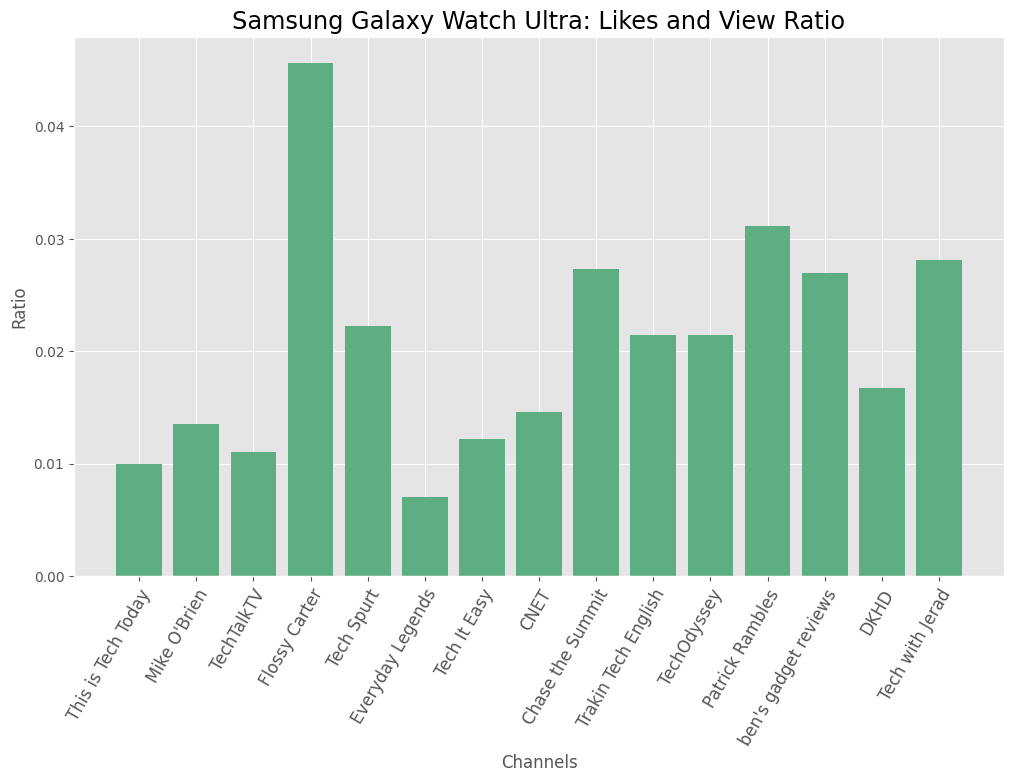

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
ax.bar(samsung_df_views.index, samsung_df_views["like_view_ratio"], color="#5DAF83")
ax.set_ylabel("Ratio")
ax.set_xlabel("Channels")
plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")
plt.title("Samsung Galaxy Watch Ultra: Likes and View Ratio", fontsize="xx-large")

plt.show()

### Views Analysis

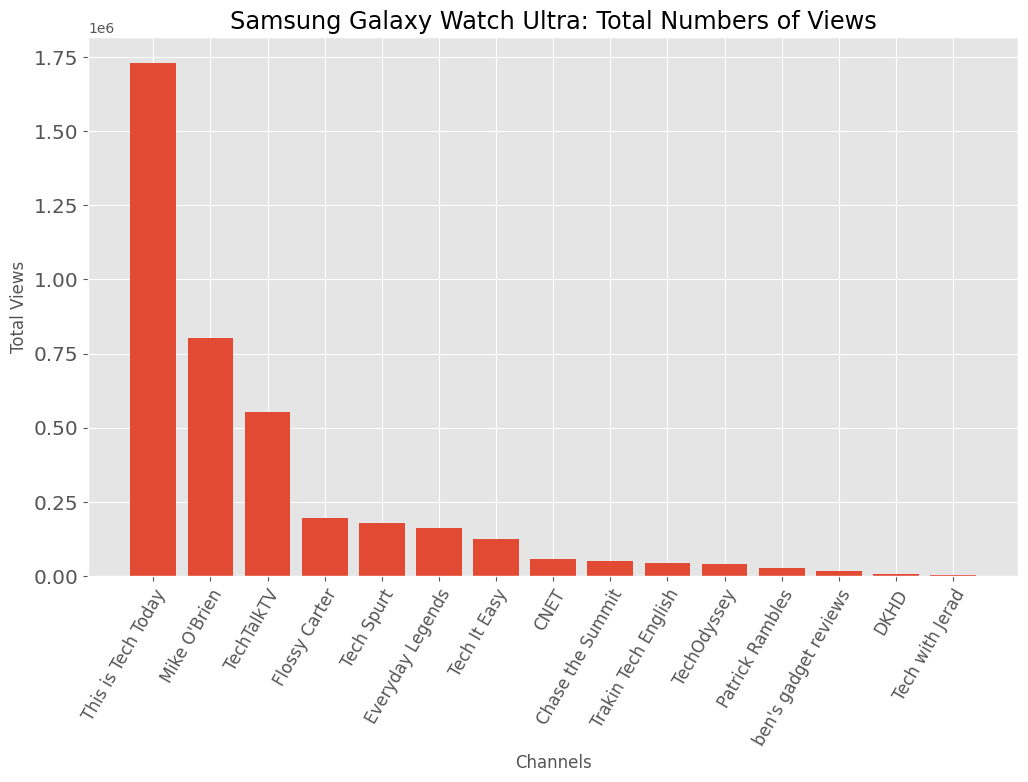

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(samsung_df_views.index, samsung_df_views["views"])

ax.set_ylabel("Total Views")
ax.set_xlabel("Channels")
plt.yticks(fontsize="x-large")

plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Samsung Galaxy Watch Ultra: Total Numbers of Views", fontsize="xx-large")  # Set the title for the whole chart.
plt.show()

The x axis, views count is decieving and not correct. The following code aims to fix this issue

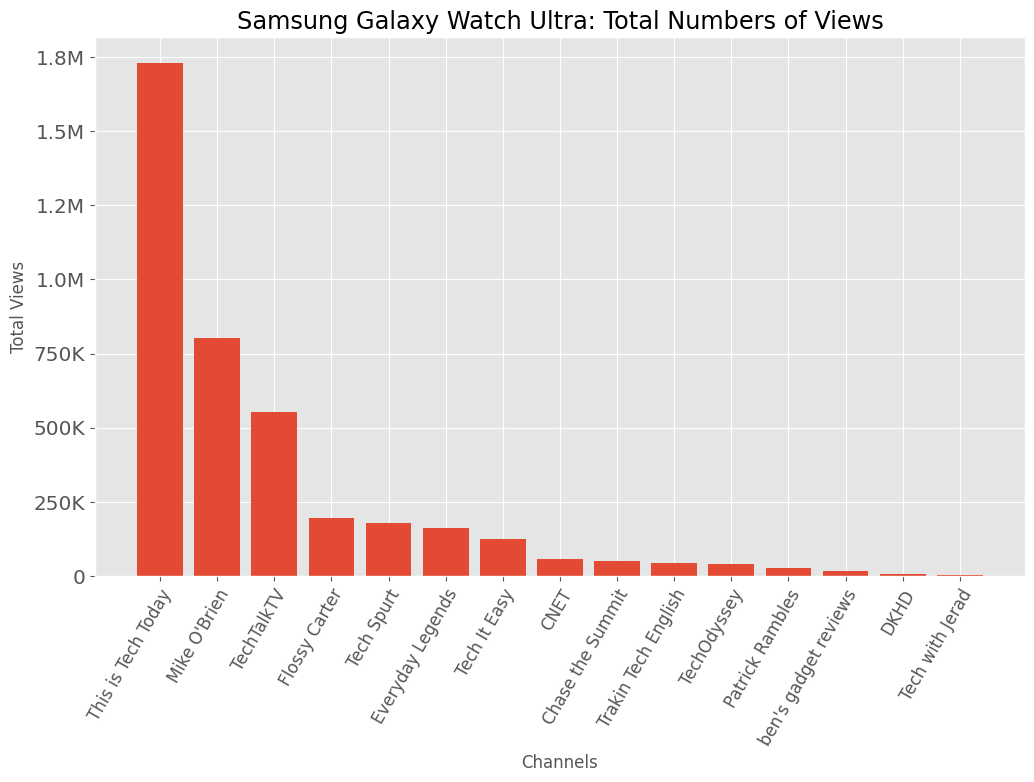

In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(samsung_df_views.index, samsung_df_views["views"])

ax.set_ylabel("Total Views")
plt.yticks(fontsize="x-large")

ax.set_xlabel("Channels")

# Define a formatter function to display values in millions or thousands
import matplotlib.ticker as ticker
def millions_formatter(x, pos):
    if x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.0f}K'
    return f'{x:.0f}'

# Apply the formatter to the y-axis
ax.yaxis.set_major_formatter(ticker.FuncFormatter(millions_formatter))

plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Samsung Galaxy Watch Ultra: Total Numbers of Views", fontsize="xx-large")  # Set the title for the whole chart.
plt.show()

### Comment Volume Analysis & Likes

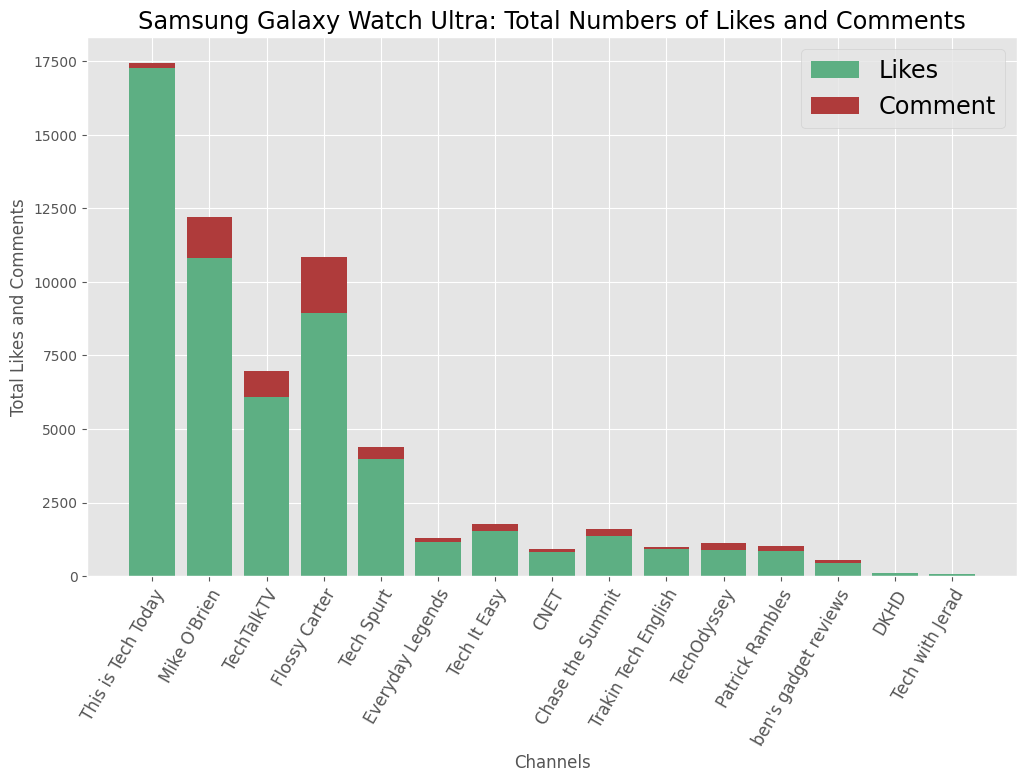

In [ ]:
plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(12, 7))

ax.bar(samsung_df_views.index, samsung_df_views["likes"], color="#5DAF83")
ax.bar(samsung_df_views.index, samsung_df_views["commentCount"], bottom=samsung_df_views["likes"], color="#AF3B3B")

ax.set_ylabel("Total Likes and Comments")
ax.set_xlabel("Channels")

plt.xticks(rotation=60, ha="right", fontsize="large", rotation_mode="anchor")

plt.title("Samsung Galaxy Watch Ultra: Total Numbers of Likes and Comments", fontsize="xx-large")

plt.legend(["Likes", "Comment"], fontsize="xx-large")  # Show the legend.
plt.show()

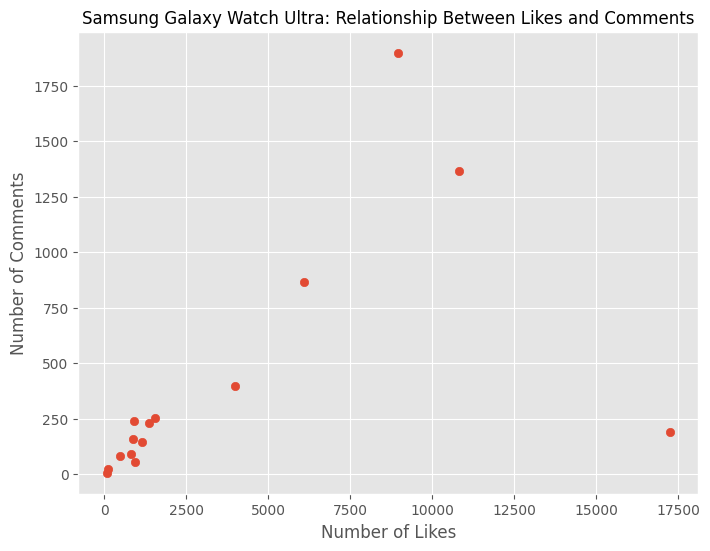

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(samsung_df_views["likes"], samsung_df_views["commentCount"])
plt.title("Samsung Galaxy Watch Ultra: Relationship Between Likes and Comments", fontsize="large")
plt.xlabel("Number of Likes")
plt.ylabel("Number of Comments")
plt.show()

### Time Series Analysis for engagement trends

In [ ]:
samsung_df_months = samsung_df.copy()
samsung_df_months["month"] = pd.to_datetime(samsung_df["publishedAt"]).apply(lambda d: d.strftime("%Y-%m"))

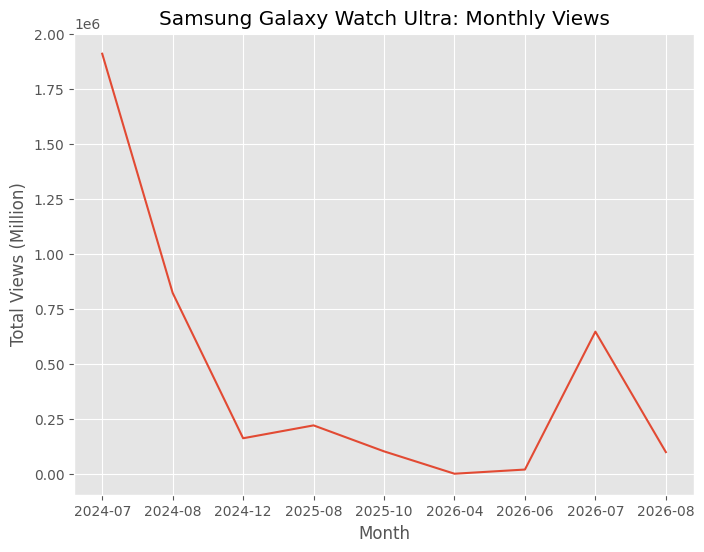

In [ ]:
samsung_df_monthly_views = samsung_df_months.groupby("month").sum()

fig, ax = plt.subplots(figsize=(8, 6))

ax.set_xlabel("Month")
ax.set_ylabel("Total Views (Million)")
plt.title("Samsung Galaxy Watch Ultra: Monthly Views")

ax.plot(samsung_df_monthly_views.index, samsung_df_monthly_views["views"])

plt.show()

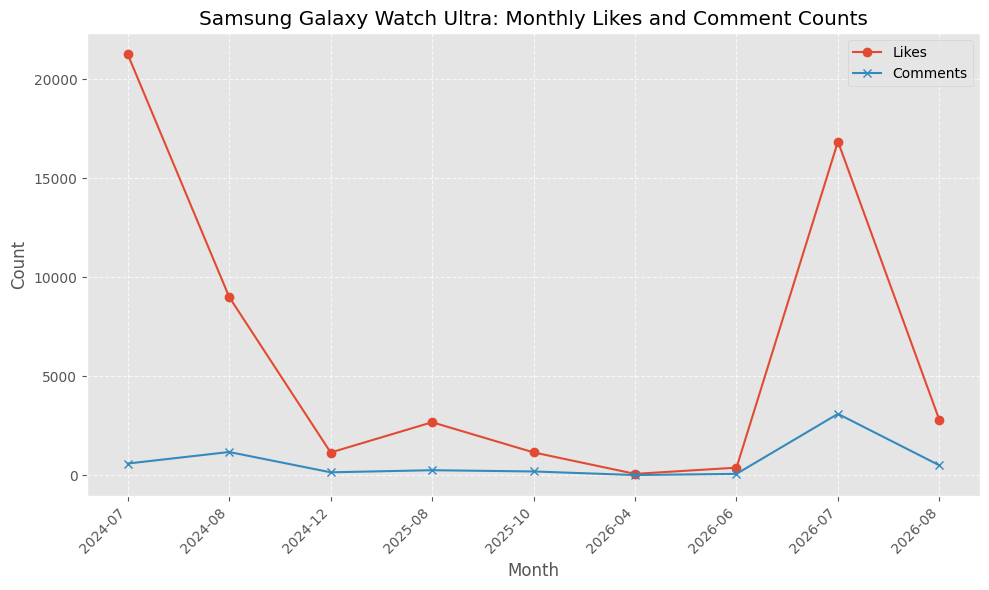

In [ ]:
samsung_df_monthly_engagement = samsung_df_months.groupby("month")[["likes", "commentCount"]].sum()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(samsung_df_monthly_engagement.index, samsung_df_monthly_engagement["likes"], label="Likes", marker='o')
ax.plot(samsung_df_monthly_engagement.index, samsung_df_monthly_engagement["commentCount"], label="Comments", marker='x')

ax.set_xlabel("Month")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.title("Samsung Galaxy Watch Ultra: Monthly Likes and Comment Counts")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()